<h2 style="color:green" align="center"> Machine Learning With Python: Linear Regression Multiple Variables</h2>

<h3 style="color:purple">Sample problem of predicting home price in monroe, new jersey (USA)</h3>

Below is the table containing home prices in monroe twp, NJ. Here price depends on **area (square feet), bed rooms and age of the home (in years)**. Given these prices we have to predict prices of new homes based on area, bed rooms and age.

<img src="homeprices.jpg" style='height:200px;width:350px'>

Given these home prices find out price of a home that has,

**3000 sqr ft area, 3 bedrooms, 40 year old**

**2500 sqr ft area, 4 bedrooms,  5 year old**

We will use regression with multiple variables here. Price can be calculated using following equation,

<img src="equation.jpg" >

Here area, bedrooms, age are called independant variables or **features** whereas price is a dependant variable

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn import linear_model

In [6]:
import os
print(os.getcwd())

/Users/kristalshrestha/Code/LLM_Scratch/MachineLearningPractice/2_linearRegressionMultivariable


In [11]:
df=pd.read_csv('homeprices.csv')

In [12]:
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


## first filling this missing value with either mode,median or mean.

In [16]:
print( df["bedrooms"].median())
print( df["bedrooms"].mode()[0])
print(df["bedrooms"].mean())

4.0
3.0
4.2


In [18]:
medianValue=df["bedrooms"].median()
print(medianValue)

4.0


# taking floor value

In [20]:
import math
medianValue=math.floor(medianValue)
print(medianValue)


4


In [23]:
df["bedrooms"]=df["bedrooms"].fillna(medianValue)

In [24]:
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [25]:
reg=linear_model.LinearRegression()

# my dependent and independent variables

In [26]:
X=df[["area","bedrooms","age"]]
y=df["price"]


In [28]:
reg.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
reg.coef_

array([  112.06244194, 23388.88007794, -3231.71790863])

In [30]:
slope1,slope2,slope3=reg.coef_

In [31]:
reg.intercept_

np.float64(221323.00186540402)

In [32]:
intercept=reg.intercept_

Given these home prices find out price of a home that has,

**3000 sqr ft area, 3 bedrooms, 40 year old**

**2500 sqr ft area, 4 bedrooms,  5 year old**

In [34]:
x1=[[3000,3,40]]

In [38]:
predictedValue1=reg.predict(x1)
print(predictedValue1)

[498408.25158031]


/Users/kristalshrestha/Code/LLM_Scratch/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [36]:
x2=[[2500,4,5]]

In [40]:
predictedValue2=reg.predict(x2)
print(predictedValue2)

[578876.03748933]


/Users/kristalshrestha/Code/LLM_Scratch/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


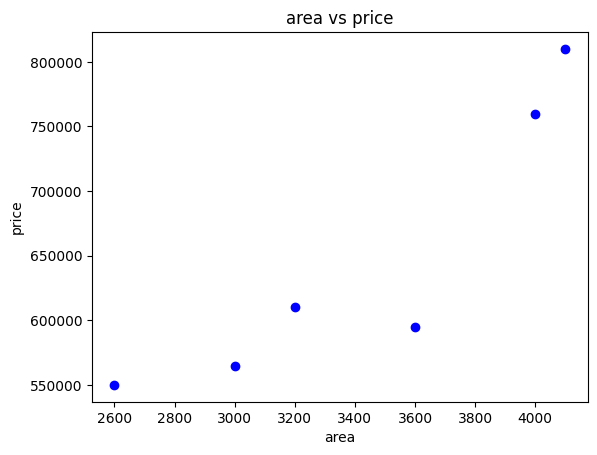

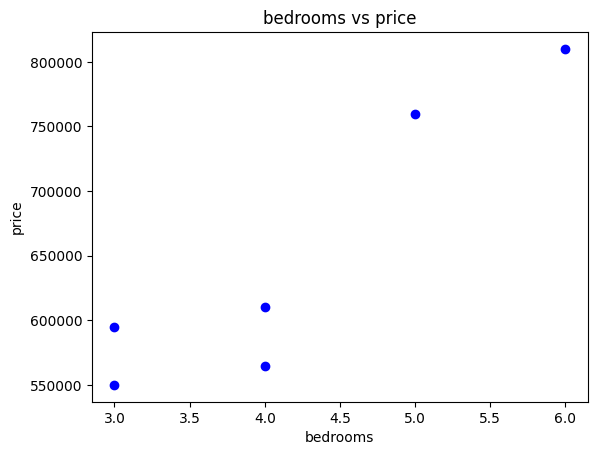

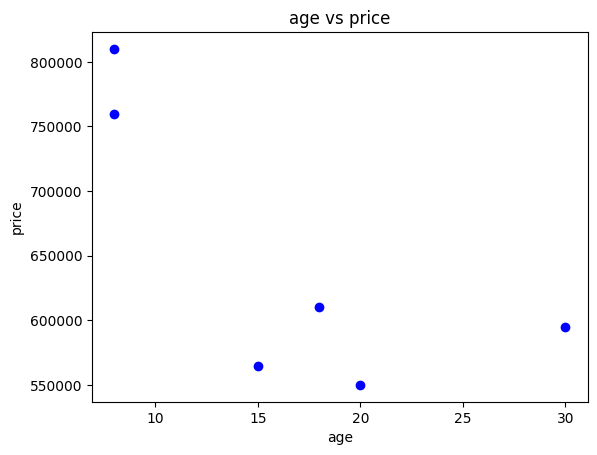

In [43]:
features = ['area', 'bedrooms', 'age']

for feature in features:
    plt.figure()
    plt.scatter(df[feature], y, color='blue')
    plt.xlabel(feature)
    plt.ylabel('price')
    plt.title(f'{feature} vs price')
    plt.show()


## features means independent variables